In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import csv
import sys
import os

subset_data_path = Path("../../data/processed/restaurants_philadelphia.csv")

df = pd.read_csv(subset_data_path)

with open(subset_data_path, mode='r', newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    for i, row in enumerate(reader):
        if i < 5:
            print(row)
        else:
            break

['business_id', 'name', 'city', 'state', 'latitude', 'longitude', 'stars', 'review_count', 'categories', 'attributes', 'is_open']
['MTSW4McQd7CbVtyjqoe9mw', 'St Honore Pastries', 'Philadelphia', 'PA', '39.9555052', '-75.1555641', '4.0', '80', 'Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries', '{\'RestaurantsDelivery\': \'False\', \'OutdoorSeating\': \'False\', \'BusinessAcceptsCreditCards\': \'False\', \'BusinessParking\': "{\'garage\': False, \'street\': True, \'validated\': False, \'lot\': False, \'valet\': False}", \'BikeParking\': \'True\', \'RestaurantsPriceRange2\': \'1\', \'RestaurantsTakeOut\': \'True\', \'ByAppointmentOnly\': \'False\', \'WiFi\': "u\'free\'", \'Alcohol\': "u\'none\'", \'Caters\': \'True\'}', '1']
['MUTTqe8uqyMdBl186RmNeA', 'Tuna Bar', 'Philadelphia', 'PA', '39.953949', '-75.1432262', '4.0', '245', 'Sushi Bars, Restaurants, Japanese', '{\'RestaurantsReservations\': \'True\', \'RestaurantsGoodForGroups\': \'True\', \'RestaurantsAttire\': "\'casual\'", \'Bu

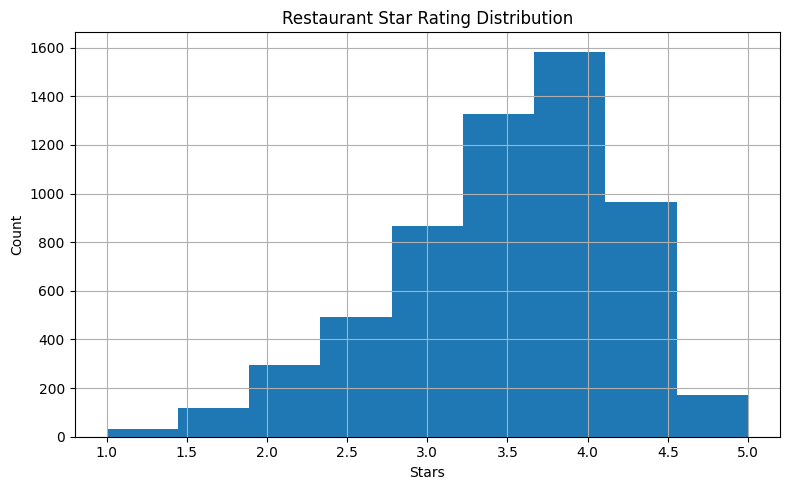

In [8]:
def plot_star_distribution(df: pd.DataFrame):
    plt.figure(figsize=(8, 5))
    df["stars"].dropna().hist(bins=9)
    plt.title("Restaurant Star Rating Distribution")
    plt.xlabel("Stars")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


plot_star_distribution(df)
    

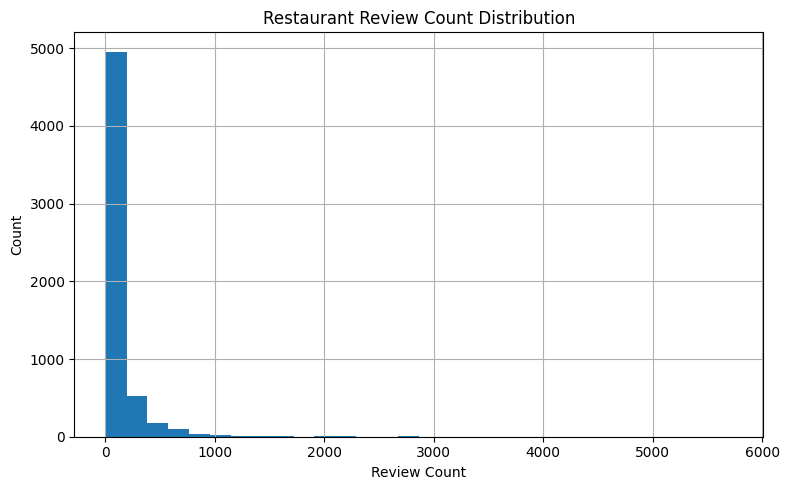

In [7]:
def plot_review_count_distribution(df: pd.DataFrame):
    plt.figure(figsize=(8, 5))
    df["review_count"].dropna().hist(bins=30)
    plt.title("Restaurant Review Count Distribution")
    plt.xlabel("Review Count")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



plot_review_count_distribution(df)


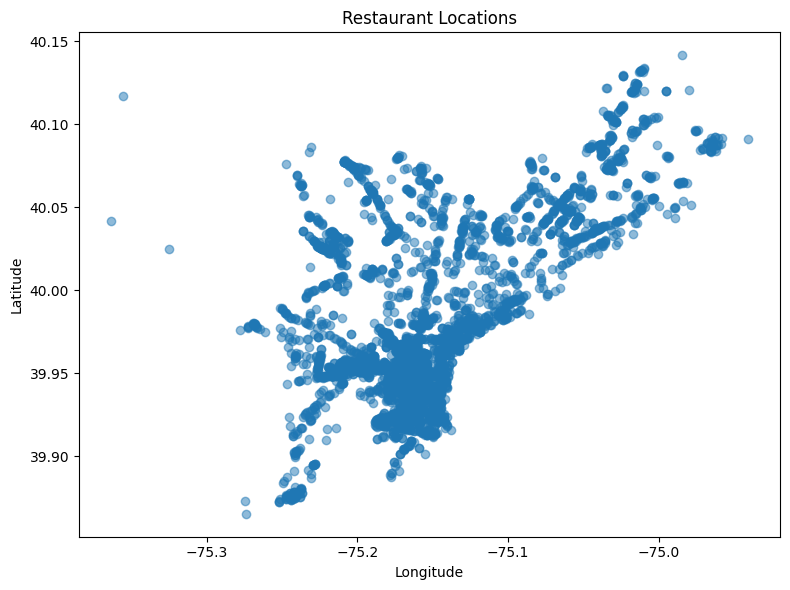

In [6]:
def plot_location_scatter(df: pd.DataFrame):
    plt.figure(figsize=(8, 6))
    plt.scatter(df["longitude"], df["latitude"], alpha=0.5)
    plt.title("Restaurant Locations")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()


plot_location_scatter(df)


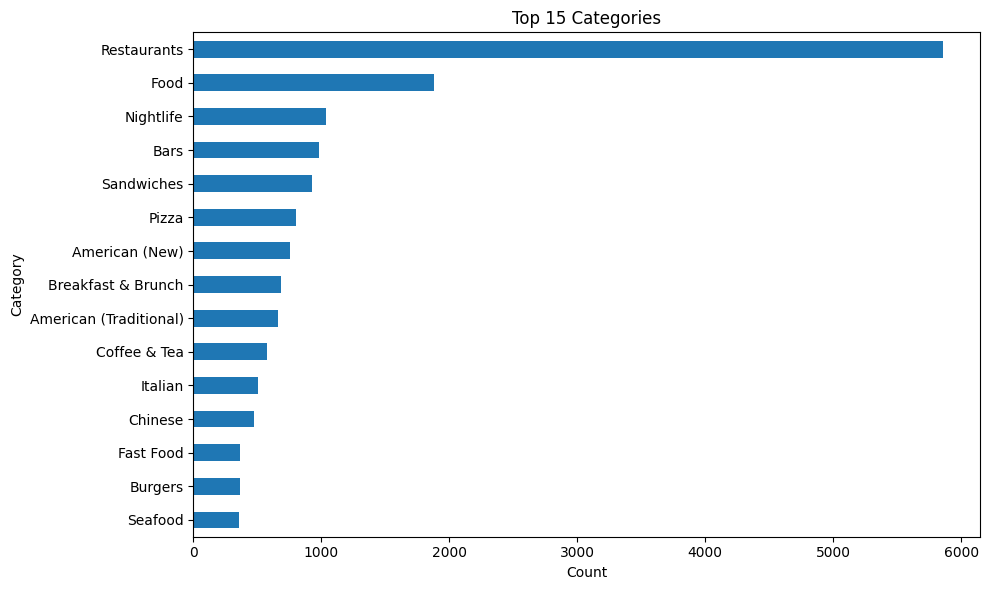

In [5]:
def plot_top_categories(df: pd.DataFrame, top_n: int = 15):
    categories_series = (
        df["categories"].dropna().str.split(", ").explode().value_counts().head(top_n)
    )

    plt.figure(figsize=(10, 6))
    categories_series.sort_values().plot(kind="barh")
    plt.title(f"Top {top_n} Categories")
    plt.xlabel("Count")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()
    
plot_top_categories(df)


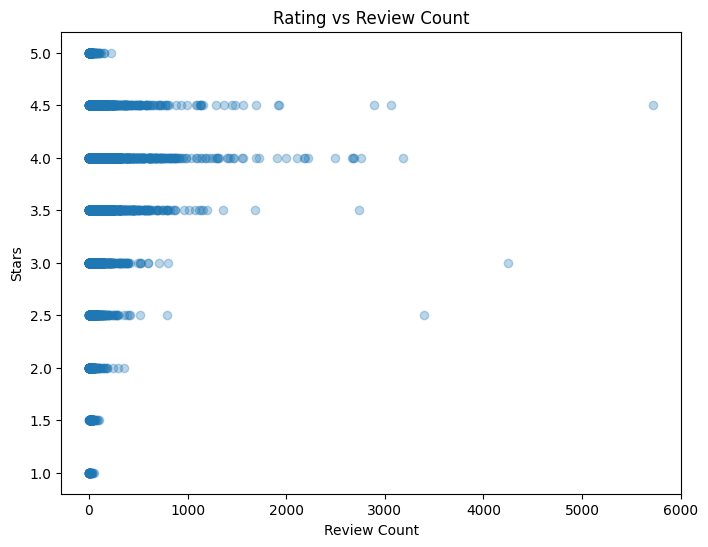

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(df["review_count"], df["stars"], alpha=0.3)
plt.xlabel("Review Count")
plt.ylabel("Stars")
plt.title("Rating vs Review Count")
plt.show()

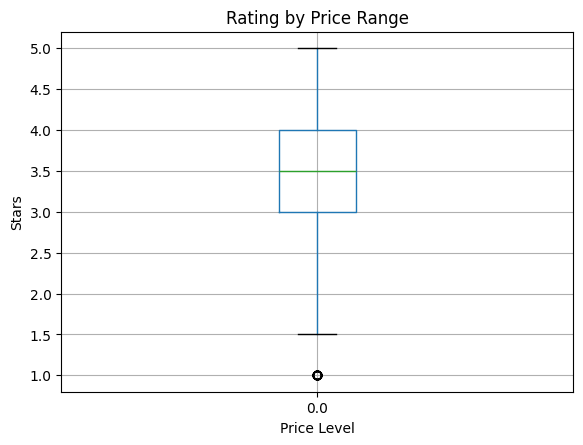

In [ ]:
### hmmm, is this right??
df["price"] = df["attributes"].apply(lambda x: str(x).count("$") if pd.notnull(x) else None)

df.boxplot(column="stars", by="price")
plt.title("Rating by Price Range")
plt.suptitle("")
plt.xlabel("Price Level")
plt.ylabel("Stars")
plt.show()

C:\Users\Gul\AppData\Local\Temp\ipykernel_58264\2383091687.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  avg = df[df["categories"].str.contains(cat, na=False)]["stars"].mean()


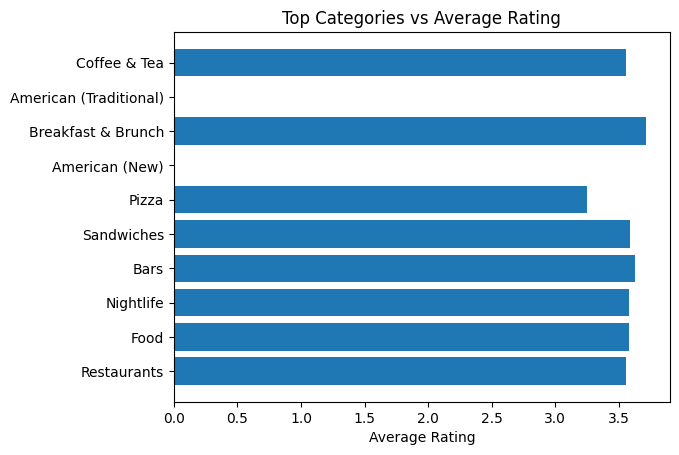

In [5]:
categories = df["categories"].dropna().str.split(", ").explode()

top_categories = categories.value_counts().head(10).index

avg_ratings = []
for cat in top_categories:
    avg = df[df["categories"].str.contains(cat, na=False)]["stars"].mean()
    avg_ratings.append(avg)

plt.barh(top_categories, avg_ratings)
plt.xlabel("Average Rating")
plt.title("Top Categories vs Average Rating")
plt.show()

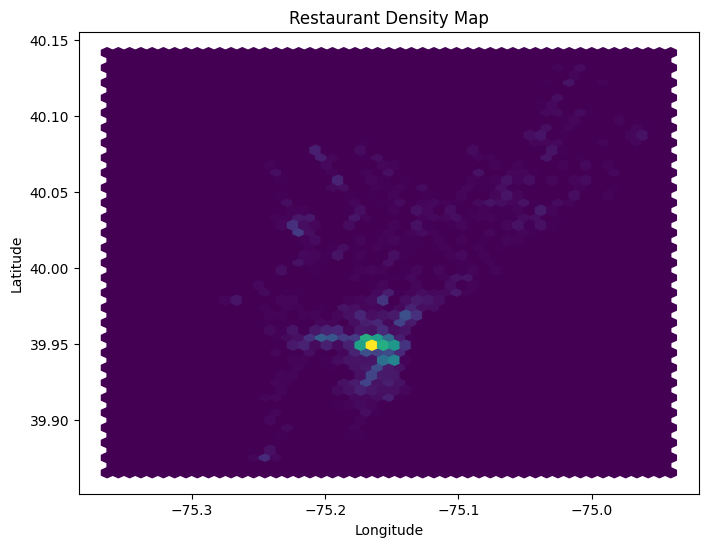

In [6]:
plt.figure(figsize=(8,6))
plt.hexbin(df["longitude"], df["latitude"], gridsize=50)
plt.title("Restaurant Density Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [7]:
review_subset_data_path = Path("../../data/processed/reviews_philadelphia.csv")

reviews_df = pd.read_csv(review_subset_data_path)

with open(review_subset_data_path, mode='r', newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    for i, row in enumerate(reader):
        if i < 5:
            print(row)
        else:
            break

['review_id', 'business_id', 'stars', 'text', 'date', 'useful']
['AqPFMleE6RsU23_auESxiA', 'kxX2SOes4o-D3ZQBkiMRfA', '5', "Wow!  Yummy, different,  delicious.   Our favorite is the lamb curry and korma.  With 10 different kinds of naan!!!  Don't let the outside deter you (because we almost changed our minds)...go in and try something new!   You'll be glad you did!", '2015-01-04 00:01:03', '1']
['JrIxlS1TzJ-iCu79ul40cQ', '04UD14gamNjLY0IDYVhHJg', '1', "I am a long term frequent customer of this establishment. I just went in to order take out (3 apps) and was told they're too busy to do it. Really? The place is maybe half full at best. Does your dick reach your ass? Yes? Go fuck yourself! I'm a frequent customer AND great tipper. Glad that Kanella just opened. NEVER going back to dmitris!", '2015-09-23 23:10:31', '1']
['8JFGBuHMoiNDyfcxuWNtrA', 'RZtGWDLCAtuipwaZ-UfjmQ', '4', "Good food--loved the gnocchi with marinara\nthe baked eggplant appetizer was very good too\n\nThe service was ver

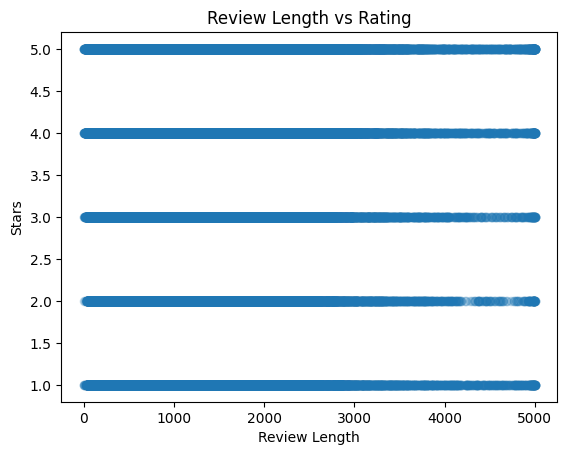

In [8]:
reviews_df["review_length"] = reviews_df["text"].str.len()

plt.scatter(reviews_df["review_length"], reviews_df["stars"], alpha=0.2)
plt.xlabel("Review Length")
plt.ylabel("Stars")
plt.title("Review Length vs Rating")
plt.show()

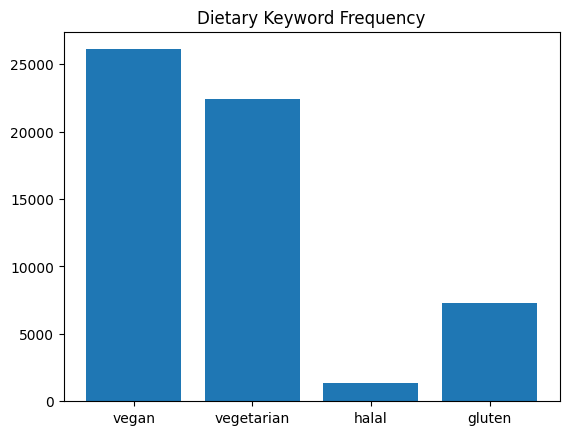

In [9]:
keywords = ["vegan", "vegetarian", "halal", "gluten"]

text = " ".join(reviews_df["text"].dropna().str.lower())

counts = {k: text.count(k) for k in keywords}

plt.bar(counts.keys(), counts.values())
plt.title("Dietary Keyword Frequency")
plt.show()